In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk pemrosesan data dan evaluasi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Mematikan peringatan agar tampilan output kode lebih rapi
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


In [9]:
# Memuat Dataset
# Pastikan nama file CSV yang di-upload sesuai dengan nama di bawah ini
df = pd.read_csv('/content/drive/MyDrive/water_potability.csv')

# Menampilkan 5 baris pertama dataset untuk memastikan data terbaca dengan benar
display(df.head())

# Menampilkan dimensi data (jumlah baris dan kolom)
print("\nUkuran dataset (baris, kolom):", df.shape)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



Ukuran dataset (baris, kolom): (3276, 10)


Jumlah Data Kosong (Null) per Kolom:


,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


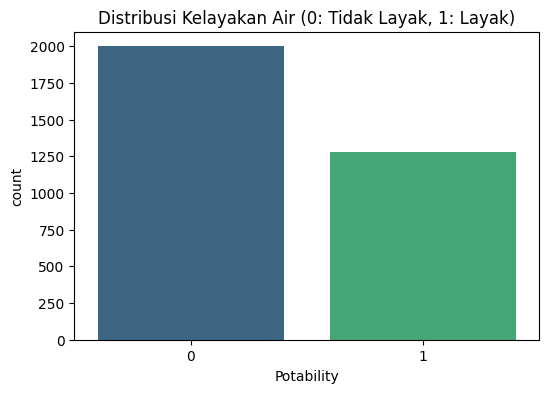

In [12]:
# Memeriksa Data Kosong dan Distribusi Target
print("Jumlah Data Kosong (Null) per Kolom:")
display(df.isnull().sum())

plt.figure(figsize=(6, 4))
sns.countplot(x='Potability', data=df, palette='viridis')
plt.title('Distribusi Kelayakan Air (0: Tidak Layak, 1: Layak)')
plt.show()

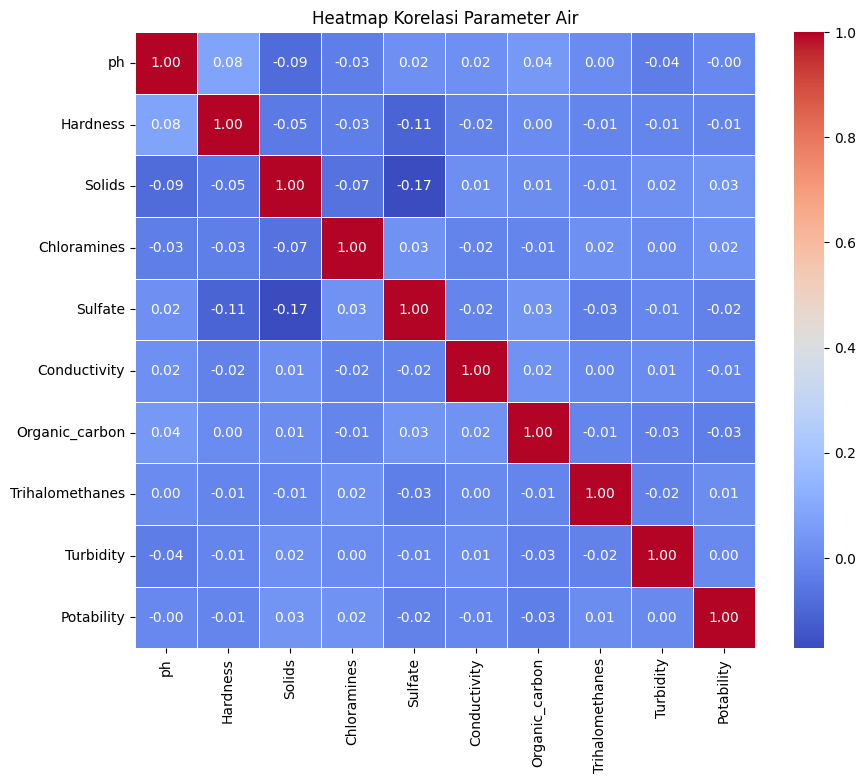

In [13]:
# Visualisasi Korelasi (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Parameter Air')
plt.show()

In [14]:
# Mengatasi Nilai Kosong (Imputasi)
df['ph'].fillna(df['ph'].mean(), inplace=True)
df['Sulfate'].fillna(df['Sulfate'].mean(), inplace=True)
df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean(), inplace=True)

print("Pengecekan ulang data kosong setelah pembersihan:")
display(df.isnull().sum())

Pengecekan ulang data kosong setelah pembersihan:


,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [15]:
# Pemisahan Data (Train-Test Split) dan Standarisasi
# Memisahkan fitur (X) dan target (y)
X = df.drop('Potability', axis=1)
y = df['Potability']

# Membagi data menjadi 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standarisasi data numerik agar skala angkanya seragam (penting untuk KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Jumlah data latih (training):", X_train.shape[0])
print("Jumlah data uji (testing):", X_test.shape[0])

Jumlah data latih (training): 2620
Jumlah data uji (testing): 656


In [16]:
# Implementasi Model (Decision Tree dan K-Nearest Neighbors)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Inisialisasi Model (max_depth dibatasi agar visualisasinya nanti tidak terlalu rumit dan mudah dibaca)
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Melatih Model menggunakan data latih yang sudah distandarisasi
dt_model.fit(X_train_scaled, y_train)
knn_model.fit(X_train_scaled, y_train)

# Melakukan Prediksi pada data uji
dt_pred = dt_model.predict(X_test_scaled)
knn_pred = knn_model.predict(X_test_scaled)

print("Proses pelatihan dan prediksi kedua model berhasil diselesaikan!")

Proses pelatihan dan prediksi kedua model berhasil diselesaikan!


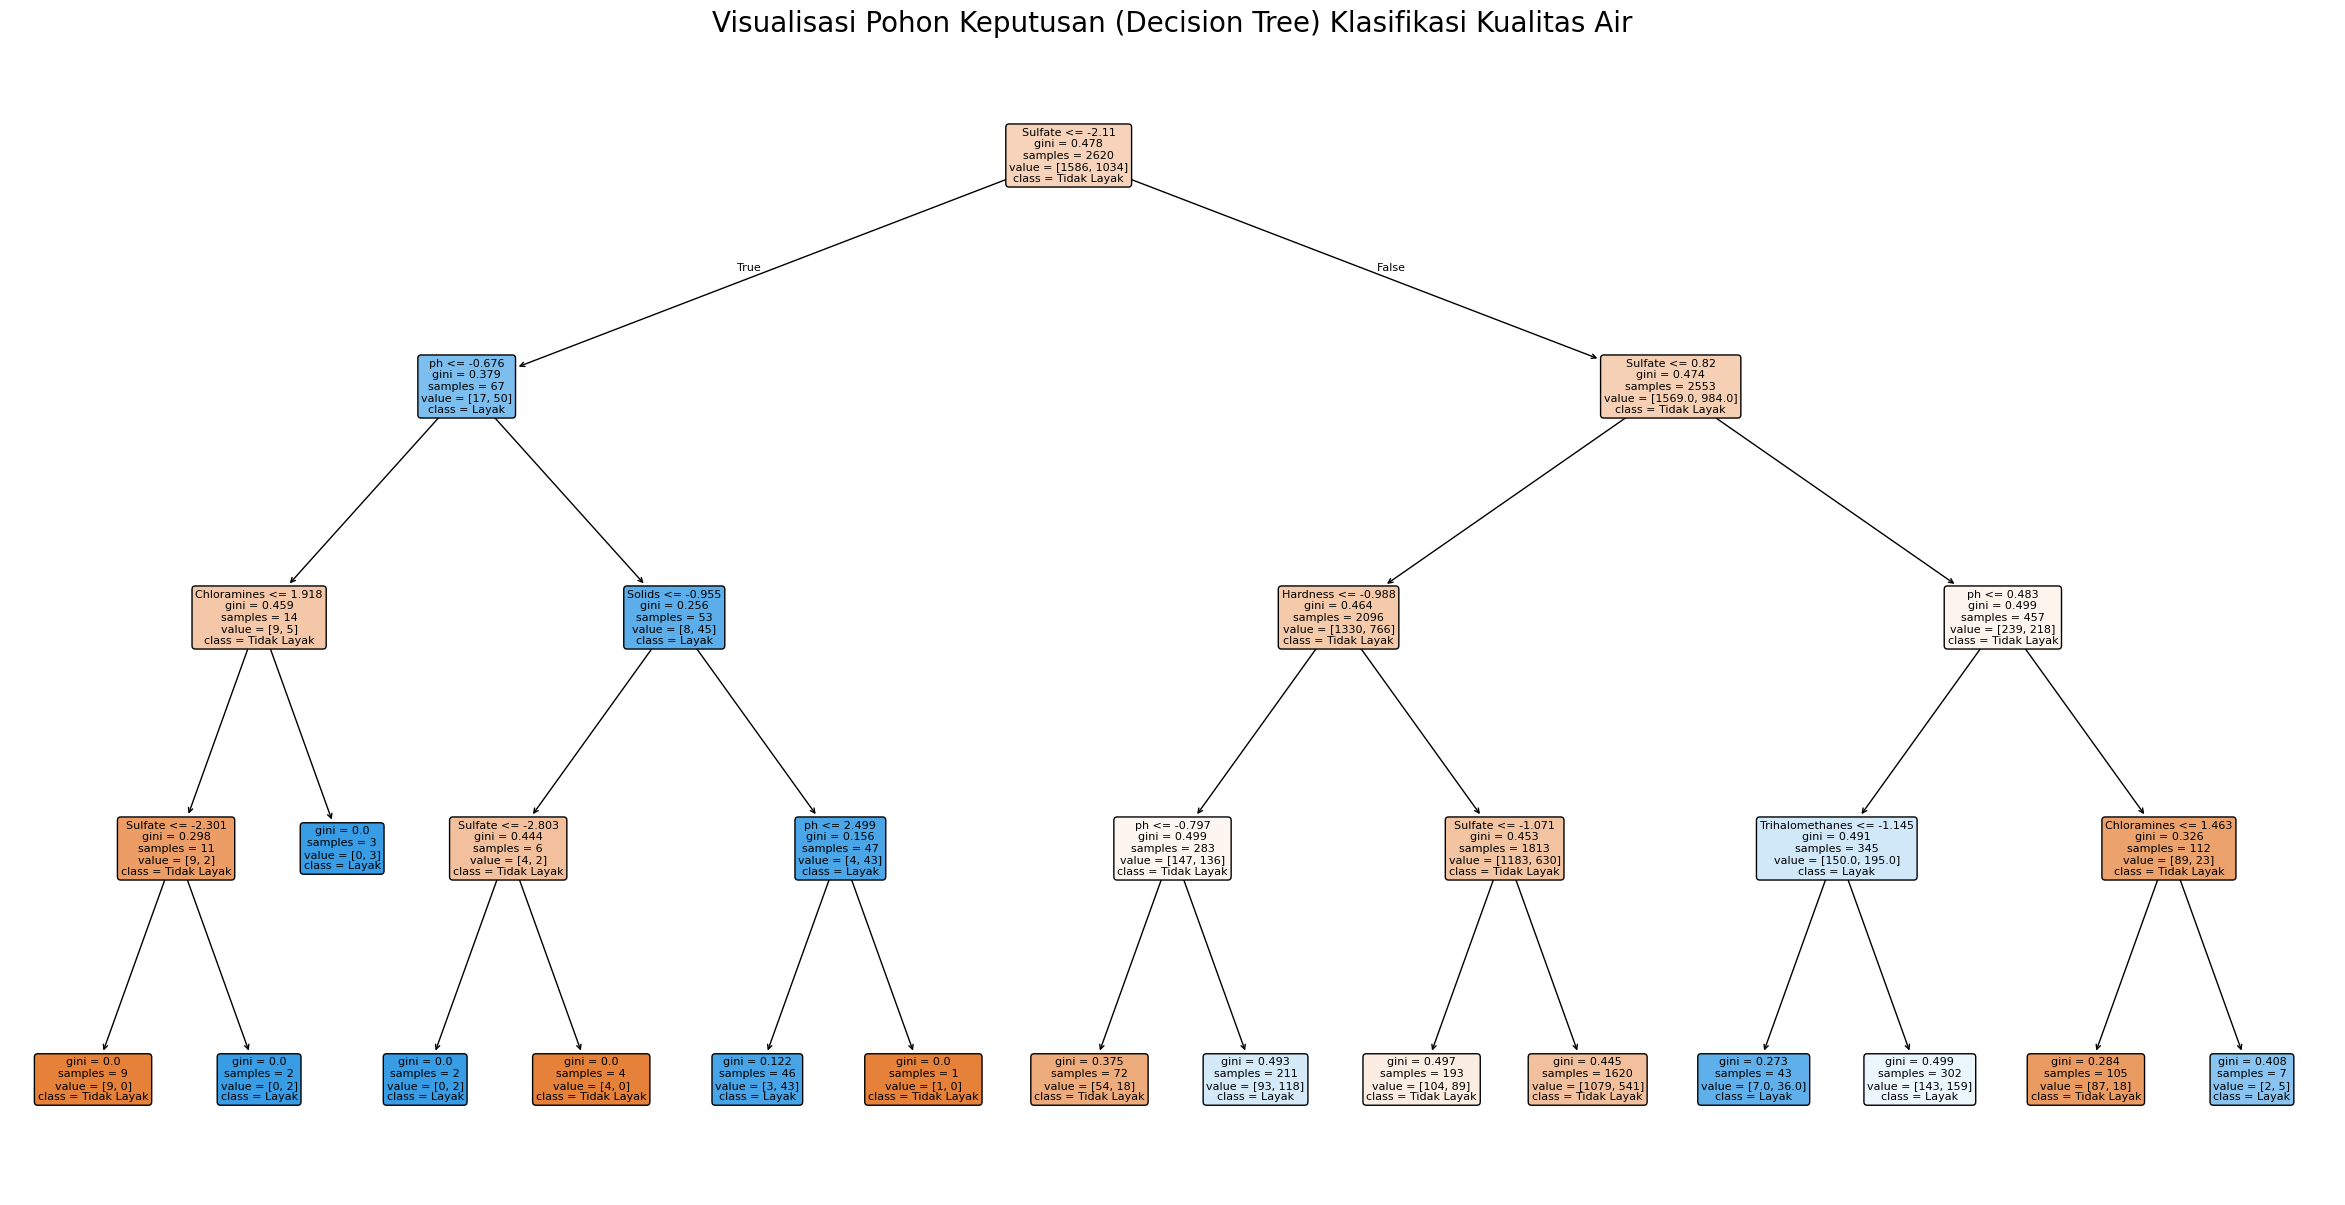

In [18]:
# Visualisasi Model Decision Tree
from sklearn.tree import plot_tree

# ukuran kanvas (30, 15)
plt.figure(figsize=(30, 15))

# fontsize
plot_tree(dt_model, feature_names=X.columns, class_names=['Tidak Layak', 'Layak'], filled=True, rounded=True, fontsize=8)

plt.title("Visualisasi Pohon Keputusan (Decision Tree) Klasifikasi Kualitas Air", fontsize=20)
plt.show()

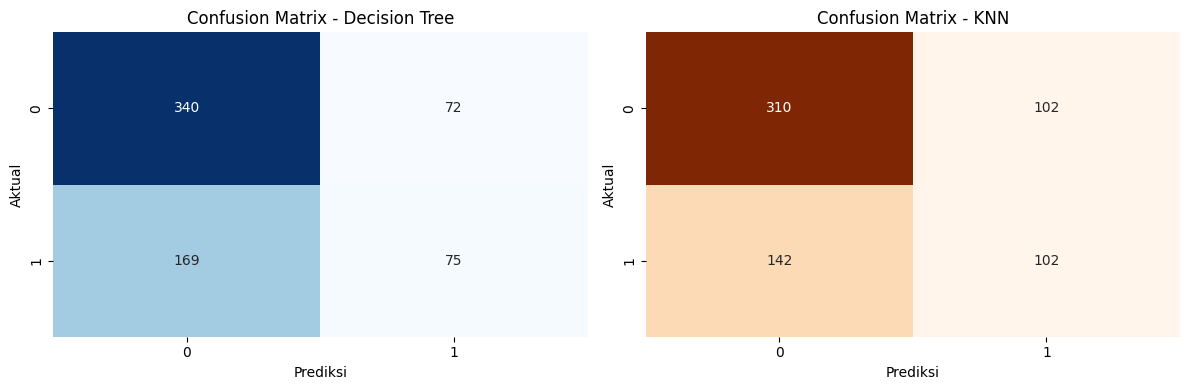

=== METRIK EVALUASI: DECISION TREE ===
Accuracy  : 63.26%
Precision : 51.02%
Recall    : 30.74%
F1-Score  : 38.36%

=== METRIK EVALUASI: K-NEAREST NEIGHBORS (KNN) ===
Accuracy  : 62.80%
Precision : 50.00%
Recall    : 41.80%
F1-Score  : 45.54%


In [19]:
# Evaluasi Model (Confusion Matrix & Metrik Evaluasi)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Visualisasi Confusion Matrix untuk Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Visualisasi Confusion Matrix untuk K-Nearest Neighbors (KNN)
cm_knn = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix - KNN')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

# Menampilkan Nilai Metrik Evaluasi
print("=== METRIK EVALUASI: DECISION TREE ===")
print(f"Accuracy  : {accuracy_score(y_test, dt_pred) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, dt_pred) * 100:.2f}%")
print(f"Recall    : {recall_score(y_test, dt_pred) * 100:.2f}%")
print(f"F1-Score  : {f1_score(y_test, dt_pred) * 100:.2f}%")

print("\n=== METRIK EVALUASI: K-NEAREST NEIGHBORS (KNN) ===")
print(f"Accuracy  : {accuracy_score(y_test, knn_pred) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, knn_pred) * 100:.2f}%")
print(f"Recall    : {recall_score(y_test, knn_pred) * 100:.2f}%")
print(f"F1-Score  : {f1_score(y_test, knn_pred) * 100:.2f}%")